═══════════════════════════════════════════════════════════════════════════
📌 Notebook 2: Análise Exploratória de Dados (EDA)
═══════════════════════════════════════════════════════════════════════════

Neste notebook vamos:
✅ Carregar os dados coletados
✅ Fazer análise estatística detalhada
✅ Criar visualizações exploratórias
✅ Identificar padrões e correlações
✅ Detectar outliers
✅ Preparar insights para o clustering

⏱️ Tempo estimado: 30-40 minutos

In [1]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 1: Setup e Importações
# ═══════════════════════════════════════════════════════════════════════════

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from scipy import stats
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Configurações
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

print("🔍 ANÁLISE EXPLORATÓRIA DE DADOS")
print("="*80)
print()
print("✅ Bibliotecas carregadas!")
print("✅ Configurações aplicadas!")

🔍 ANÁLISE EXPLORATÓRIA DE DADOS

✅ Bibliotecas carregadas!
✅ Configurações aplicadas!


In [2]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 2: Carregar dados
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd

print("\n" + "="*80)
print("📂 CARREGANDO DADOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Carregar dataset
data_path = base_path / 'data/raw/municipios_completo.csv'

if not data_path.exists():
    print(f"❌ ERRO: Arquivo não encontrado: {data_path}")
    print("   Execute o notebook 01_coleta_dados.ipynb primeiro!")
else:
    df = pd.read_csv(data_path)
    print(f"✅ Dados carregados: {data_path}")
    print()
    print(f"📊 Dimensões: {df.shape[0]:,} linhas × {df.shape[1]} colunas")
    print()
    print("📋 Primeiras linhas:")
    display(df.head())



📂 CARREGANDO DADOS

✅ Dados carregados: ..\data\raw\municipios_completo.csv

📊 Dimensões: 5,565 linhas × 14 colunas

📋 Primeiras linhas:


,codigo_ibge,nome_municipio,uf,nome_uf,regiao,populacao,pib_milhoes,area_km2,pib_per_capita,taxa_alfabetizacao,mortalidade_infantil,esgoto_adequado,estabelecimentos_saude,densidade
0,1100015,Alta Floresta D'Oeste,RO,Rondônia,Norte,22787,734.47,7067.00,32231.84,86.36,21.01,53.21,5.56,3.22
1,1100023,Ariquemes,RO,Rondônia,Norte,109170,3211.29,4426.60,29415.54,85.06,21.84,62.97,23.83,24.66
2,1100031,Cabixi,RO,Rondônia,Norte,5664,238.41,1314.40,42092.87,86.77,20.91,63.24,1.13,4.31
3,1100049,Cacoal,RO,Rondônia,Norte,98280,2792.51,3792.80,28413.78,88.37,20.22,66.78,23.66,25.91
4,1100056,Cerejeiras,RO,Rondônia,Norte,16966,743.06,2783.30,43797.12,85.03,17.51,62.39,3.39,6.10


In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 3: Visão geral dos dados
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📊 VISÃO GERAL DO DATASET")
print("="*80)
print()

# Informações básicas
print("🔢 TIPOS DE DADOS:")
print(df.dtypes)
print()

# Valores únicos
print("🎯 VALORES ÚNICOS POR COLUNA:")
for col in df.columns:
    n_unique = df[col].nunique()
    print(f"   {col:30s}: {n_unique:6,} valores únicos")

print()
print("❓ VALORES AUSENTES:")
missing = df.isnull().sum()
if missing.sum() == 0:
    print("   ✅ Nenhum valor ausente!")
else:
    missing_pct = (missing / len(df)) * 100
    missing_df = pd.DataFrame({
        'Ausentes': missing[missing > 0],
        'Percentual': missing_pct[missing > 0]
    }).sort_values('Ausentes', ascending=False)
    print(missing_df)


📊 VISÃO GERAL DO DATASET

🔢 TIPOS DE DADOS:
codigo_ibge                 int64
nome_municipio             object
uf                         object
nome_uf                    object
regiao                     object
populacao                   int64
pib_milhoes               float64
area_km2                  float64
pib_per_capita            float64
taxa_alfabetizacao        float64
mortalidade_infantil      float64
esgoto_adequado           float64
estabelecimentos_saude    float64
densidade                 float64
dtype: object

🎯 VALORES ÚNICOS POR COLUNA:
   codigo_ibge                   :  5,565 valores únicos
   nome_municipio                :  5,292 valores únicos
   uf                            :     27 valores únicos
   nome_uf                       :     27 valores únicos
   regiao                        :      5 valores únicos
   populacao                     :  5,099 valores únicos
   pib_milhoes                   :  5,546 valores únicos
   area_km2                      :  

In [4]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 4: Estatísticas descritivas detalhadas
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📈 ESTATÍSTICAS DESCRITIVAS")
print("="*80)
print()

# Selecionar colunas numéricas
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_cols = [col for col in numeric_cols if col != 'codigo_ibge']

print(f"📊 Analisando {len(numeric_cols)} variáveis numéricas:")
print()

# Estatísticas detalhadas
stats_df = df[numeric_cols].describe(percentiles=[.01, .05, .25, .5, .75, .95, .99])
display(stats_df)

# Análise de assimetria e curtose
print("\n📐 ASSIMETRIA E CURTOSE:")
print("(Indica se distribuições são normais)")
print()
print("Assimetria (Skewness):")
print("  • = 0: Distribuição simétrica (normal)")
print("  • > 0: Cauda à direita (poucos valores muito altos)")
print("  • < 0: Cauda à esquerda (poucos valores muito baixos)")
print()
print("Curtose (Kurtosis):")
print("  • ≈ 3: Distribuição normal")
print("  • > 3: Picos acentuados (leptocúrtica)")
print("  • < 3: Achatada (platicúrtica)")
print()

skew_kurt = pd.DataFrame({
    'Assimetria': df[numeric_cols].skew(),
    'Curtose': df[numeric_cols].kurtosis()
}).round(2)

display(skew_kurt)

print()
print("💡 INTERPRETAÇÃO:")
for col in numeric_cols:
    skew = df[col].skew()
    if abs(skew) > 2:
        print(f"   ⚠️  {col}: Altamente assimétrica (skew={skew:.2f})")
        print(f"      → Considerar transformação logarítmica")


📈 ESTATÍSTICAS DESCRITIVAS

📊 Analisando 9 variáveis numéricas:



,populacao,pib_milhoes,area_km2,pib_per_capita,taxa_alfabetizacao,mortalidade_infantil,esgoto_adequado,estabelecimentos_saude,densidade
count,5565.00,5565.00,5565.00,5565.00,5565.00,5565.00,5565.00,5565.00,5565.00
mean,38338.26,1619.06,1527.89,33305.06,85.38,19.60,61.22,9.67,121.08
std,217534.74,13780.71,5622.29,37742.30,2.03,2.06,5.20,43.57,622.21
min,856.00,18.05,3.60,5145.05,79.03,10.16,43.10,1.00,0.15
1%,1721.00,33.14,43.43,7447.97,80.74,14.73,48.90,1.00,0.91
5%,2489.40,49.35,83.00,9004.21,82.09,16.19,52.91,1.37,2.45
25%,5346.00,112.60,204.60,13230.17,84.03,18.21,57.66,2.92,11.65
50%,11362.00,253.17,416.40,23810.07,85.38,19.61,61.14,4.64,24.94
75%,25300.00,680.98,1025.10,40370.97,86.71,20.98,64.65,7.45,55.72
95%,118727.80,4985.07,5343.94,83514.72,88.71,22.91,69.72,25.82,298.73



📐 ASSIMETRIA E CURTOSE:
(Indica se distribuições são normais)

Assimetria (Skewness):
  • = 0: Distribuição simétrica (normal)
  • > 0: Cauda à direita (poucos valores muito altos)
  • < 0: Cauda à esquerda (poucos valores muito baixos)

Curtose (Kurtosis):
  • ≈ 3: Distribuição normal
  • > 3: Picos acentuados (leptocúrtica)
  • < 3: Achatada (platicúrtica)



,Assimetria,Curtose
populacao,36.51,1772.27
pib_milhoes,44.29,2453.07
area_km2,13.49,252.37
pib_per_capita,6.77,86.17
taxa_alfabetizacao,0.06,0.13
mortalidade_infantil,-0.06,0.14
esgoto_adequado,0.07,0.31
estabelecimentos_saude,36.50,1772.80
densidade,13.26,219.43



💡 INTERPRETAÇÃO:
   ⚠️  populacao: Altamente assimétrica (skew=36.51)
      → Considerar transformação logarítmica
   ⚠️  pib_milhoes: Altamente assimétrica (skew=44.29)
      → Considerar transformação logarítmica
   ⚠️  area_km2: Altamente assimétrica (skew=13.49)
      → Considerar transformação logarítmica
   ⚠️  pib_per_capita: Altamente assimétrica (skew=6.77)
      → Considerar transformação logarítmica
   ⚠️  estabelecimentos_saude: Altamente assimétrica (skew=36.50)
      → Considerar transformação logarítmica
   ⚠️  densidade: Altamente assimétrica (skew=13.26)
      → Considerar transformação logarítmica



📊 VISUALIZANDO DISTRIBUIÇÕES

✅ Gráfico salvo: ..\outputs\figures\01_distribuicoes.png


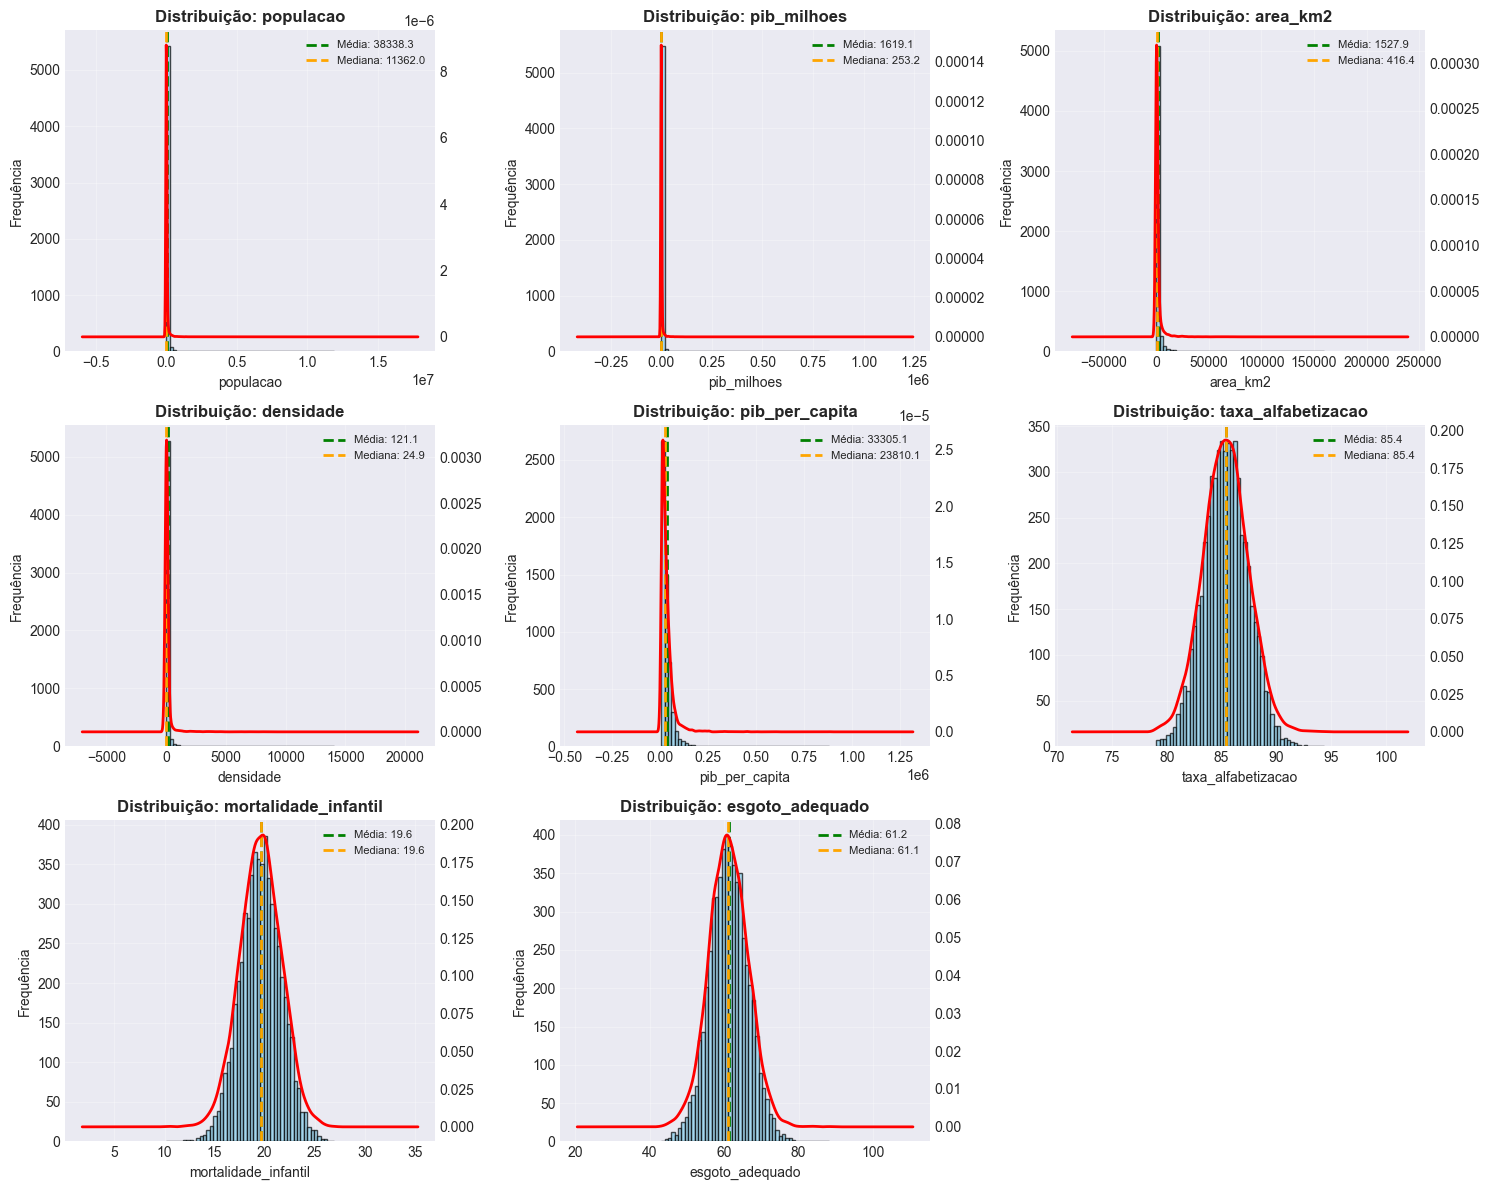

In [5]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 5: Distribuições - Histogramas
# ═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("📊 VISUALIZANDO DISTRIBUIÇÕES")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída dos gráficos
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# Selecionar variáveis principais para visualização
viz_cols = [
    'populacao', 'pib_milhoes', 'area_km2', 'densidade',
    'pib_per_capita', 'taxa_alfabetizacao',
    'mortalidade_infantil', 'esgoto_adequado'
]

# Filtrar apenas colunas existentes
viz_cols = [col for col in viz_cols if col in df.columns]

# Criar subplots
n_cols = 3
n_rows = (len(viz_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(viz_cols):
    ax = axes[idx]
    
    # Histograma
    df[col].hist(bins=50, ax=ax, alpha=0.7, color='skyblue', edgecolor='black')
    
    # KDE
    df[col].plot(kind='kde', ax=ax, secondary_y=True, color='red', linewidth=2)
    
    ax.set_title(f'Distribuição: {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col, fontsize=10)
    ax.set_ylabel('Frequência', fontsize=10)
    ax.grid(True, alpha=0.3)
    
    # Estatísticas
    mean_val = df[col].mean()
    median_val = df[col].median()
    ax.axvline(mean_val, color='green', linestyle='--', linewidth=2, label=f'Média: {mean_val:.1f}')
    ax.axvline(median_val, color='orange', linestyle='--', linewidth=2, label=f'Mediana: {median_val:.1f}')
    ax.legend(fontsize=8)

# Remover subplots vazios
for idx in range(len(viz_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

# Salvar figura
output_file = output_dir / '01_distribuicoes.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")

plt.show()



📦 ANÁLISE DE OUTLIERS (BOXPLOTS)

✅ Gráfico salvo: ..\outputs\figures\02_boxplots.png


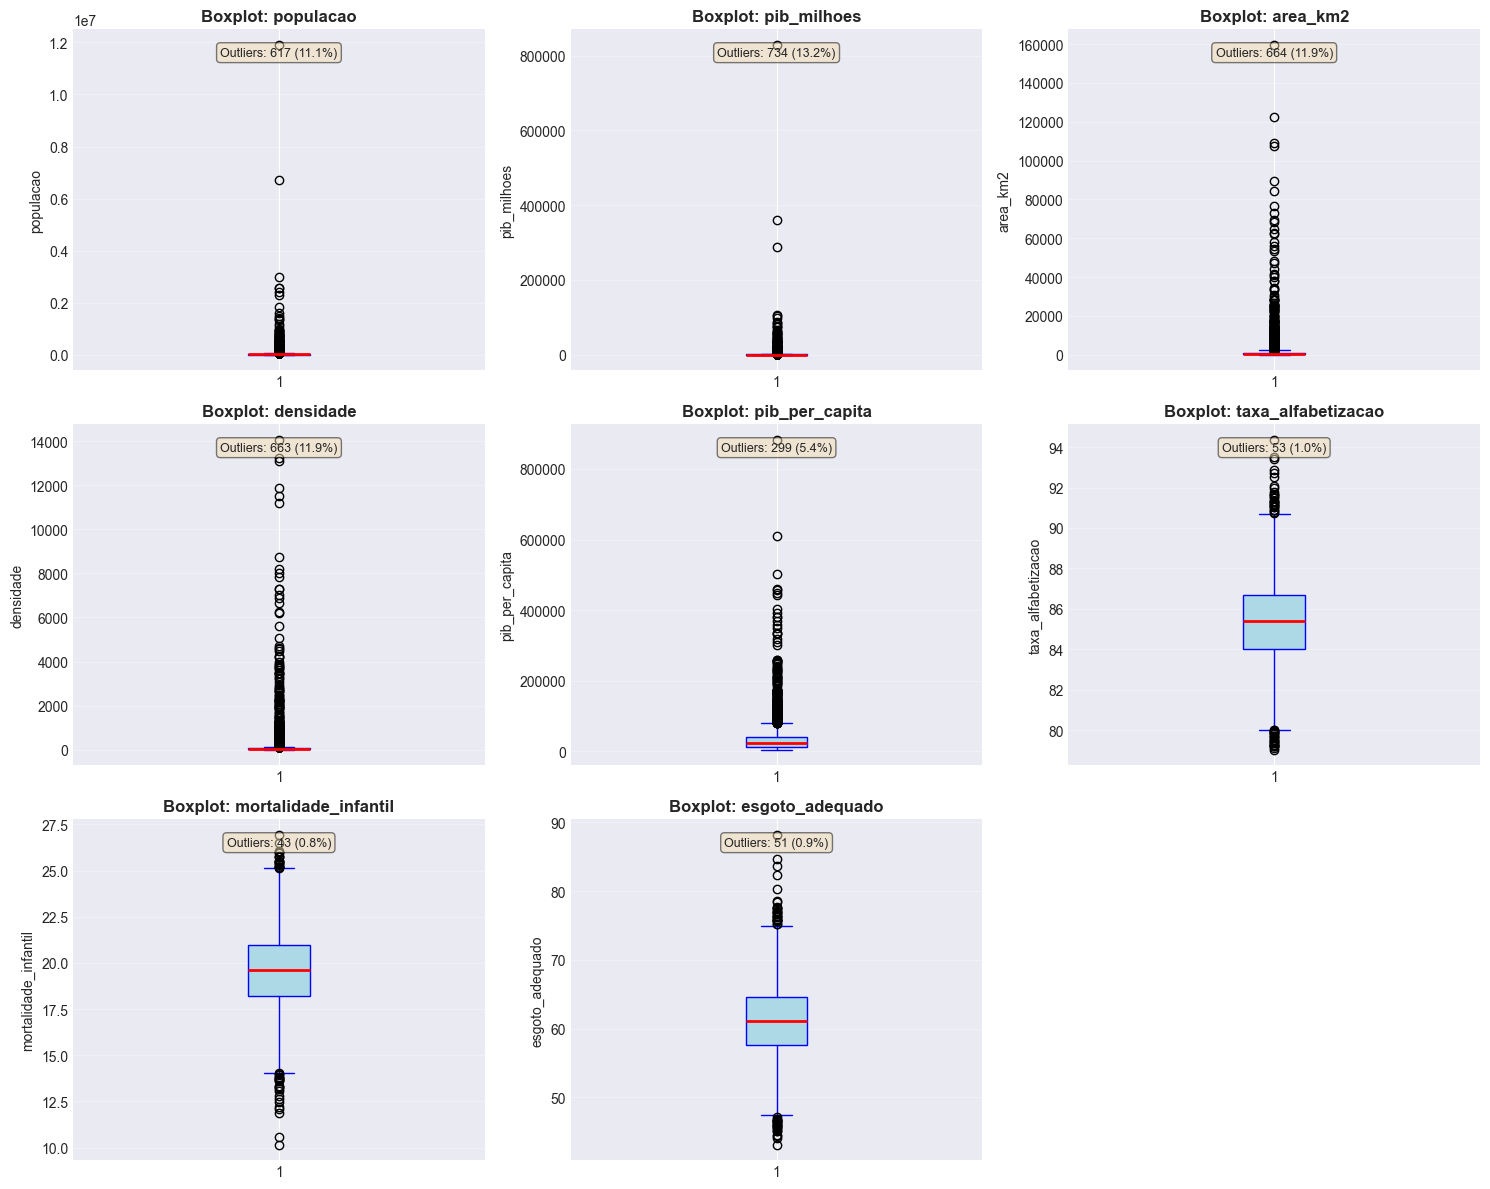


💡 INTERPRETAÇÃO DOS BOXPLOTS:
   • Caixa: 50% dos dados (Q1 a Q3)
   • Linha vermelha: Mediana
   • Bigodes: Até 1.5 × IQR
   • Pontos fora: Outliers


In [6]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 6: Boxplots para detectar outliers
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("📦 ANÁLISE DE OUTLIERS (BOXPLOTS)")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída dos gráficos
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(viz_cols):
    ax = axes[idx]
    
    # Boxplot
    bp = ax.boxplot(df[col].dropna(), vert=True, patch_artist=True,
                    boxprops=dict(facecolor='lightblue', color='blue'),
                    medianprops=dict(color='red', linewidth=2),
                    whiskerprops=dict(color='blue'),
                    capprops=dict(color='blue'))
    
    ax.set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel(col, fontsize=10)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Calcular e mostrar quantis
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    
    ax.text(0.5, 0.95, f'Outliers: {n_outliers} ({n_outliers/len(df)*100:.1f}%)',
            transform=ax.transAxes, ha='center', va='top',
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
            fontsize=9)

# Remover subplots vazios
for idx in range(len(viz_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()

# Salvar figura
output_file = output_dir / '02_boxplots.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")
plt.show()

print("\n💡 INTERPRETAÇÃO DOS BOXPLOTS:")
print("   • Caixa: 50% dos dados (Q1 a Q3)")
print("   • Linha vermelha: Mediana")
print("   • Bigodes: Até 1.5 × IQR")
print("   • Pontos fora: Outliers")


🔗 MATRIZ DE CORRELAÇÃO

✅ Gráfico salvo: ..\outputs\figures\03_correlacao.png


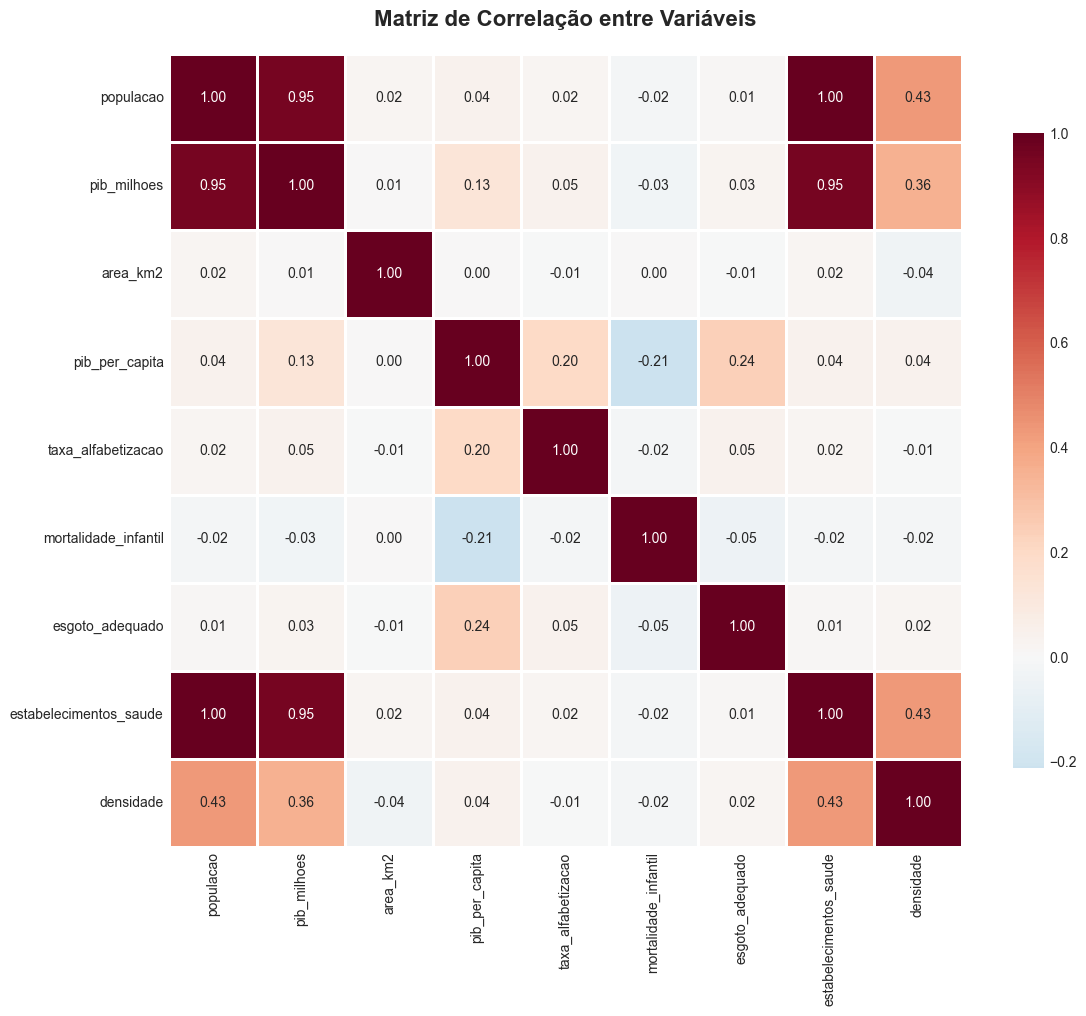


🔍 CORRELAÇÕES FORTES (|r| > 0.7):

   • populacao ↔ pib_milhoes: r = 0.955
   • populacao ↔ estabelecimentos_saude: r = 0.999
   • pib_milhoes ↔ estabelecimentos_saude: r = 0.954


In [7]:
# ═══════════════════════════════════════════════════════════════════════════
# CÉLULA 7: Matriz de correlação
# ═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🔗 MATRIZ DE CORRELAÇÃO")
print("="*80)
print()

# Calcular correlações
correlation_matrix = df[numeric_cols].corr()

# Visualizar com heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlação entre Variáveis', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
output_file = output_dir / '03_correlacao.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"✅ Gráfico salvo: {output_file}")
plt.show()

# Identificar correlações fortes
print("\n🔍 CORRELAÇÕES FORTES (|r| > 0.7):")
print()
strong_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.7:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            strong_corr.append((var1, var2, corr_val))
            print(f"   • {var1} ↔ {var2}: r = {corr_val:.3f}")
            if not strong_corr:
                print("   ℹ️  Nenhuma correlação forte detectada")

In [8]:
#═══════════════════════════════════════════════════════════════════════════
#CÉLULA 8: Scatterplots interativos (Plotly)
#═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import plotly.express as px

print("\n" + "="*80)
print("📈 GRÁFICOS DE DISPERSÃO INTERATIVOS")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# População vs PIB (colorido por região)
# -------------------------------------------------------------------------
fig = px.scatter(
    df,
    x='populacao',
    y='pib_milhoes',
    color='regiao',
    hover_data=['nome_municipio', 'uf'],
    title='População vs PIB por Região',
    labels={
        'populacao': 'População',
        'pib_milhoes': 'PIB (milhões R$)'
    },
    log_x=True,
    log_y=True,
    height=600
)

fig.update_traces(marker=dict(size=8, opacity=0.6))
fig.update_layout(template='plotly_white')

output_file_1 = output_dir / '04_scatter_pop_pib.html'
fig.write_html(output_file_1)
print(f"✅ Gráfico interativo salvo: {output_file_1}")
fig.show()

# -------------------------------------------------------------------------
# PIB per capita vs Taxa de alfabetização
# -------------------------------------------------------------------------
fig = px.scatter(
    df,
    x='pib_per_capita',
    y='taxa_alfabetizacao',
    color='regiao',
    hover_data=['nome_municipio', 'uf', 'populacao'],
    title='PIB per Capita vs Taxa de Alfabetização',
    labels={
        'pib_per_capita': 'PIB per Capita (R$)',
        'taxa_alfabetizacao': 'Taxa de Alfabetização (%)'
    },
    height=600
)

fig.update_traces(marker=dict(size=8, opacity=0.6))
fig.update_layout(template='plotly_white')

output_file_2 = output_dir / '05_scatter_pib_alfabet.html'
fig.write_html(output_file_2)
print(f"✅ Gráfico interativo salvo: {output_file_2}")
fig.show()



📈 GRÁFICOS DE DISPERSÃO INTERATIVOS

✅ Gráfico interativo salvo: ..\outputs\figures\04_scatter_pop_pib.html


✅ Gráfico interativo salvo: ..\outputs\figures\05_scatter_pib_alfabet.html



🗺️ ANÁLISE POR REGIÃO

📊 ESTATÍSTICAS POR REGIÃO:


populacao                             pib_milhoes          \
                 count       sum     mean   median         sum    mean   
regiao                                                                   
Centro-Oeste       466  17227099 36968.02  9501.50   930869.03 1997.57   
Nordeste          1794  57244485 31908.85 14177.00  1243103.27  692.92   
Norte              449  18775464 41816.18 16552.00   563775.36 1255.62   
Sudeste           1668  88825643 53252.78 11140.00  4712981.73 2825.53   
Sul               1188  31279712 26329.72  7298.50  1559339.14 1312.58   

             pib_per_capita          densidade taxa_alfabetizacao  \
                       mean   median      mean               mean   
regiao                                                              
Centro-Oeste       52663.87 37946.52     38.87              85.52   
Nordeste           16308.13 11783.06     97.20              85.27   
Norte              26911.90 19725.76     24.79              85.34   
Sudeste            36721.29 25650.43    216.86              85.40   
Sul                48998.26 41964.99     91.32              85.49   

             esgoto_adequado  
                        mean  
regiao                        
Centro-Oeste           61.77  
Nordeste               60.64  
Norte                  60.91  
Sudeste                61.44  
Sul                    61.71


✅ Gráfico salvo: ..\outputs\figures\06_analise_regional.png


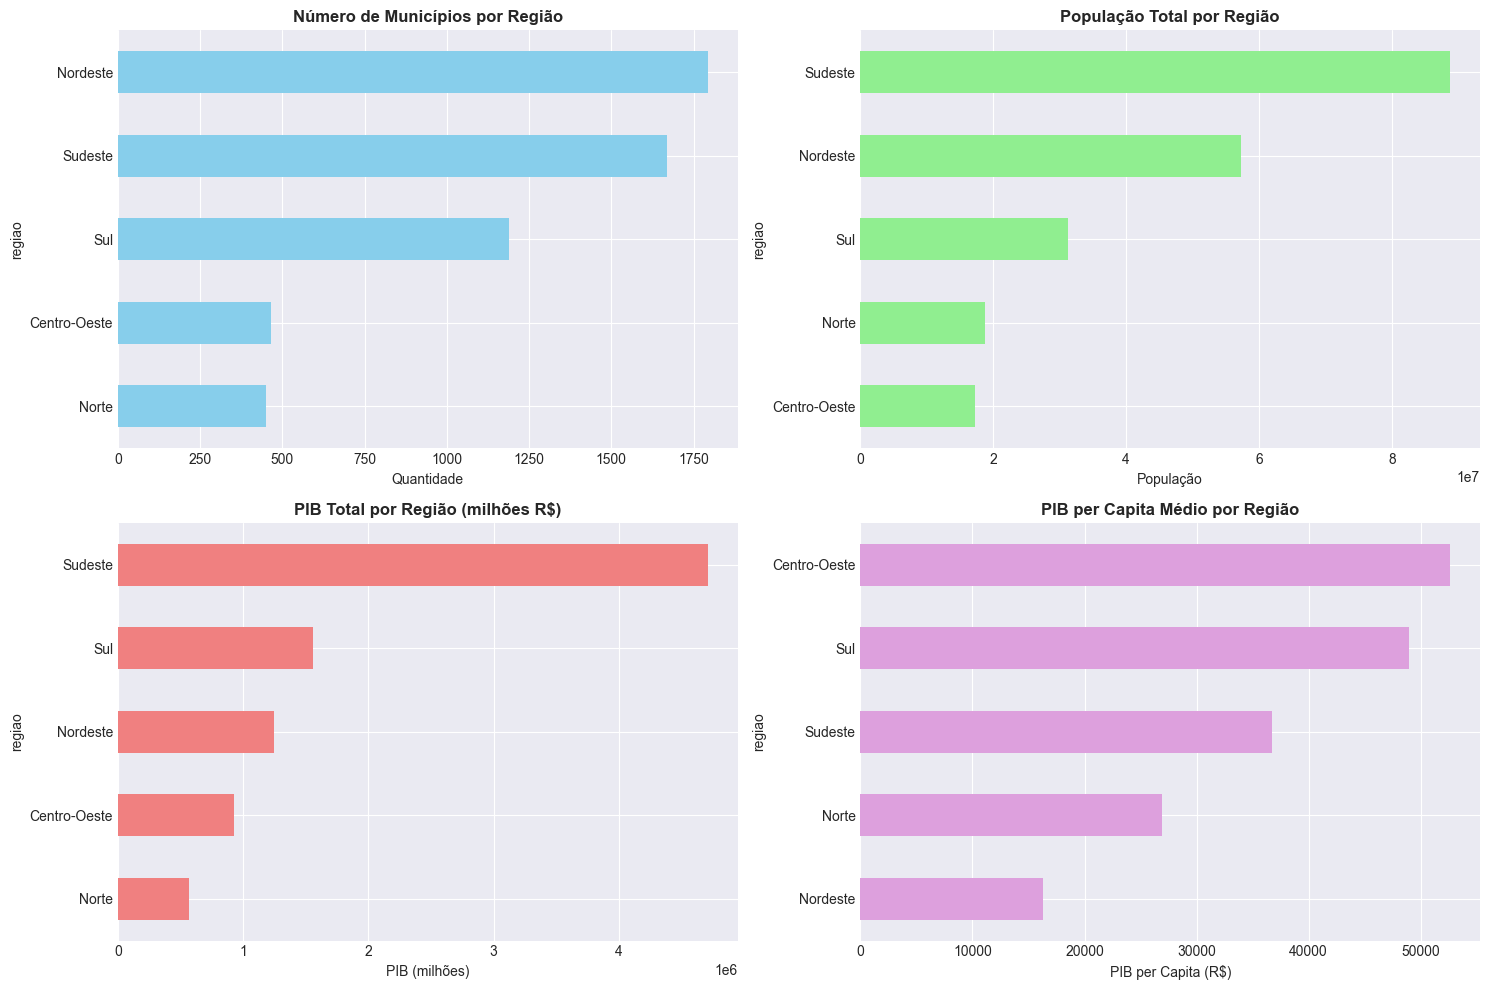

In [9]:
#═══════════════════════════════════════════════════════════════════════════
#CÉLULA 9: Análise por região
#═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import matplotlib.pyplot as plt

print("\n" + "="*80)
print("🗺️ ANÁLISE POR REGIÃO")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída
output_dir = base_path / 'outputs/figures'
output_dir.mkdir(parents=True, exist_ok=True)

# -------------------------------------------------------------------------
# Estatísticas por região
# -------------------------------------------------------------------------
regional_stats = (
    df.groupby('regiao')
      .agg({
          'populacao': ['count', 'sum', 'mean', 'median'],
          'pib_milhoes': ['sum', 'mean'],
          'pib_per_capita': ['mean', 'median'],
          'densidade': 'mean',
          'taxa_alfabetizacao': 'mean',
          'esgoto_adequado': 'mean'
      })
      .round(2)
)

print("📊 ESTATÍSTICAS POR REGIÃO:")
display(regional_stats)

# -------------------------------------------------------------------------
# Gráficos de barras
# -------------------------------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Número de municípios
df['regiao'].value_counts().sort_values().plot(
    kind='barh', ax=axes[0, 0], color='skyblue'
)
axes[0, 0].set_title('Número de Municípios por Região', fontweight='bold')
axes[0, 0].set_xlabel('Quantidade')

# População total
df.groupby('regiao')['populacao'].sum().sort_values().plot(
    kind='barh', ax=axes[0, 1], color='lightgreen'
)
axes[0, 1].set_title('População Total por Região', fontweight='bold')
axes[0, 1].set_xlabel('População')

# PIB total
df.groupby('regiao')['pib_milhoes'].sum().sort_values().plot(
    kind='barh', ax=axes[1, 0], color='lightcoral'
)
axes[1, 0].set_title('PIB Total por Região (milhões R$)', fontweight='bold')
axes[1, 0].set_xlabel('PIB (milhões)')

# PIB per capita médio
df.groupby('regiao')['pib_per_capita'].mean().sort_values().plot(
    kind='barh', ax=axes[1, 1], color='plum'
)
axes[1, 1].set_title('PIB per Capita Médio por Região', fontweight='bold')
axes[1, 1].set_xlabel('PIB per Capita (R$)')

plt.tight_layout()

# Salvar figura
output_file = output_dir / '06_analise_regional.png'
plt.savefig(output_file, dpi=300, bbox_inches='tight')
print(f"\n✅ Gráfico salvo: {output_file}")

plt.show()

In [10]:
#═══════════════════════════════════════════════════════════════════════════
#CÉLULA 10: Top municípios
#═══════════════════════════════════════════════════════════════════════════

print("\n" + "="*80)
print("🏆 RANKINGS DE MUNICÍPIOS")
print("="*80)

#Top 20 por população
print("\n📍 TOP 20 MUNICÍPIOS POR POPULAÇÃO:")
top_pop = df.nlargest(20, 'populacao')[['nome_municipio', 'uf', 'populacao', 'pib_per_capita']]
display(top_pop)

#Top 20 por PIB
print("\n💰 TOP 20 MUNICÍPIOS POR PIB:")
top_pib = df.nlargest(20, 'pib_milhoes')[['nome_municipio', 'uf', 'pib_milhoes', 'populacao']]
display(top_pib)

#Top 20 por PIB per capita
print("\n💎 TOP 20 MUNICÍPIOS POR PIB PER CAPITA:")
top_pib_pc = df.nlargest(20, 'pib_per_capita')[['nome_municipio', 'uf', 'pib_per_capita', 'populacao']]
display(top_pib_pc)


🏆 RANKINGS DE MUNICÍPIOS

📍 TOP 20 MUNICÍPIOS POR POPULAÇÃO:


,nome_municipio,uf,populacao,pib_per_capita
3828,São Paulo,SP,11904961,69633.22
3241,Rio de Janeiro,RJ,6730729,53431.46
5564,Brasília,DF,2996899,95746.90
948,Fortaleza,CE,2578483,28480.99
2161,Salvador,BA,2564204,24561.75
2308,Belo Horizonte,MG,2415872,43843.74
111,Manaus,AM,2303732,44832.21
4004,Curitiba,PR,1830795,53528.93
1595,Recife,PE,1588376,34607.86
5412,Goiânia,GO,1503256,39827.21



💰 TOP 20 MUNICÍPIOS POR PIB:


,nome_municipio,uf,pib_milhoes,populacao
3828,São Paulo,SP,828980.75,11904961
3241,Rio de Janeiro,RJ,359632.65,6730729
5564,Brasília,DF,286943.78,2996899
2308,Belo Horizonte,MG,105920.86,2415872
111,Manaus,AM,103281.40,2303732
4004,Curitiba,PR,98000.49,1830795
3653,Osasco,SP,86111.26,759524
3214,Maricá,RJ,85814.19,212470
4927,Porto Alegre,RS,81563.06,1388794
3478,Guarulhos,SP,77376.43,1349100



💎 TOP 20 MUNICÍPIOS POR PIB PER CAPITA:


,nome_municipio,uf,pib_per_capita,populacao
2409,Catas Altas,MG,881936.03,5706
2964,São Gonçalo do Rio Abaixo,MG,609522.08,12475
2623,Itatiaiuçu,MG,503255.82,13779
3154,Presidente Kennedy,ES,458646.85,14852
5064,Triunfo,RS,456564.23,28435
3676,Paulínia,SP,449024.09,116674
3254,Saquarema,RJ,442513.34,95315
3214,Maricá,RJ,403888.49,212470
183,Canaã dos Carajás,PA,390821.62,89524
4868,Muitos Capões,RS,382051.75,2937


In [11]:
#═══════════════════════════════════════════════════════════════════════════
#CÉLULA 11: Salvar resumo da análise
#═══════════════════════════════════════════════════════════════════════════

from pathlib import Path
import pandas as pd

print("\n" + "="*80)
print("💾 SALVANDO RESUMO DA ANÁLISE")
print("="*80)
print()

# Caminho base (sobe de notebooks/ para projeto_5/)
base_path = Path('..')

# Diretório de saída
output_dir = base_path / 'outputs/results'
output_dir.mkdir(parents=True, exist_ok=True)

# Caminho do arquivo
output_path = output_dir / 'analise_exploratoria.xlsx'

# Criar relatório em Excel com múltiplas abas
with pd.ExcelWriter(output_path, engine='openpyxl') as writer:
    # Estatísticas descritivas
    stats_df.to_excel(writer, sheet_name='Estatisticas_Descritivas')
    
    # Correlações
    correlation_matrix.to_excel(writer, sheet_name='Correlacoes')
    
    # Análise regional
    regional_stats.to_excel(writer, sheet_name='Analise_Regional')
    
    # Rankings
    top_pop.to_excel(writer, sheet_name='Top_Populacao', index=False)
    top_pib.to_excel(writer, sheet_name='Top_PIB', index=False)
    top_pib_pc.to_excel(writer, sheet_name='Top_PIB_per_Capita', index=False)

print(f"✅ Relatório salvo: {output_path}")
print()
print("="*80)
print("🎉 ANÁLISE EXPLORATÓRIA CONCLUÍDA!")
print("="*80)
print()
print("📊 PRINCIPAIS INSIGHTS:")
print()
print("   ✅ Distribuições analisadas")
print("   ✅ Outliers identificados")
print("   ✅ Correlações mapeadas")
print("   ✅ Padrões regionais descobertos")
print("   ✅ Visualizações geradas e salvas")
print()
print("👉 PRÓXIMO PASSO:")
print("   Abra o notebook: 03_preprocessamento.ipynb")
print()
print("="*80)


💾 SALVANDO RESUMO DA ANÁLISE

✅ Relatório salvo: ..\outputs\results\analise_exploratoria.xlsx

🎉 ANÁLISE EXPLORATÓRIA CONCLUÍDA!

📊 PRINCIPAIS INSIGHTS:

   ✅ Distribuições analisadas
   ✅ Outliers identificados
   ✅ Correlações mapeadas
   ✅ Padrões regionais descobertos
   ✅ Visualizações geradas e salvas

👉 PRÓXIMO PASSO:
   Abra o notebook: 03_preprocessamento.ipynb

